Initialize the SBI task


In [ ]:
# !pip install git+"https://github.com/nidropakshin2/Sequential-FMPE.git#egg=sfmpe&subdirectory=code"
# !pip3 install torch torchvision --index-url https://download.pytorch.org/whl/cu126

In [ ]:
config = {
    "prior":
        {
        "mu_loc": 0.0,
        "mu_scale": 0.2,
        "phi_alpha": 20.0,
        "phi_beta": 1.5,
        "sigma_ig_shape": 2.5,
        "sigma_ig_scale": 0.025,
        "m_loc": -1.5,
        "m_scale": 1.0,
        },
    "simulator":
        {
        "T": [200, 250],
        "v0": [-5, 5],
        },
    "summary": 
        {
        "type": "lstm",
        "input_dim": 1,
        "hidden_dim": 32,
        "num_layers": 3,
        "output_dim": 20,
        "dropout": 0.1,
        },
    "logger":
        {
        "name": "StochVol",
        "level": "DEBUG",
        "log_file_path": "logs/stoch_vol.log",
        }
}
import os

if not os.path.exists("./logs"):
    os.mkdir("./logs")
if not os.path.exists("./models"):
    os.mkdir("./models")

In [ ]:
import yaml
import torch
import time
import matplotlib.pyplot as plt


from sfmpe.tasks.SIR import SIRTask


# config_path = './configs/sir_config.yaml'
# with open(config_path) as f:
#     config = yaml.safe_load(f)
device = 'cpu'
task = SIRTask(config, device)
task.summary.to(device)
logger = task.logger
logger.info("Starting SIR task")

2026-07-18 11:07:36,209 - SIR - INFO - Starting SIR task


In [ ]:
from sfmpe.inference.fm_estimator import FlowMatchingEstimator
from sfmpe.flow.flow_model import FlowModel
from sfmpe.flow.velocity import SimpleVelocityField
from sfmpe.flow.path import AffinePath
from sfmpe.core.distributions import Uniform, Normal


init_dist = Normal(dim=task.theta_dim)
velocity_model = SimpleVelocityField(task.theta_dim, task.data_dim)
path = AffinePath()
flow_model = FlowModel(velocity_model, init_dist, path)
logger.info("Initialized flow model")

# optimizer = torch.optim.Adam(flow_model.velocity_model.parameters(), lr=1e-4)
optimizer = torch.optim.Adam([
                        {"params": task.summary.parameters(), "lr":1e-4},
                        {"params": flow_model.parameters(), "lr":1e-4}
                        ])
loss_fn = torch.nn.MSELoss()

def preprocessor(theta, x):
    s = task.simulate(theta).to(device)
    x = task.summarize(s).to(device)
    return theta, x


fm_estimator = FlowMatchingEstimator(flow_model, optimizer, loss_fn, dataset_prepocessor=preprocessor)
logger.info("Initialized flow matching estimator")

2026-07-18 11:07:36,237 - SIR - INFO - Initialized flow model
2026-07-18 11:07:36,237 - SIR - INFO - Initialized flow matching estimator


In [ ]:
from sfmpe.inference.sequential.round_manager import RoundManager
from sfmpe.inference.sequential.proposal import Proposal, ProposalParams

# theta_0, x_0 = task.simulate_dataset((1,))
theta_0 = torch.tensor([[1.6667, 0.4016]])
x_0 = task.summarize(task.simulate(theta_0))
# theta_0, x_0 = theta_0.expand(5, -1), x_0.expand(5, -1)
task.logger.info(f"Starting SFMPE for theta {theta_0}")

params = ProposalParams()
params.task = task
params.method = "NPE-A"
params.theta_0 = theta_0
params.x_0 = x_0
params.method_params = {'scale': 0.8, 'quantile': 0.3}


2026-07-18 11:07:36,280 - SIR - INFO - Starting SFMPE for theta tensor([[1.6667, 0.4016]])


In [ ]:
theta = task.prior.sample((1,))
s = task.summarize(task.simulate(theta.expand(1000, *theta.shape)))
print(theta)
s.max(dim=0)[0], s.mean(dim=0), s.min(dim=0)[0], s.std(dim=0)

tensor([[0.7563, 0.3890]])


(tensor([[-0.1296,  0.0748,  0.0032, -0.0458, -0.0123]], grad_fn=<MaxBackward0>),
 tensor([[-0.2129, -0.0163, -0.0947, -0.1031, -0.0712]],
        grad_fn=<MeanBackward1>),
 tensor([[-0.2773, -0.0777, -0.1485, -0.1813, -0.1428]], grad_fn=<MinBackward0>),
 tensor([[0.0219, 0.0201, 0.0221, 0.0190, 0.0202]], grad_fn=<StdBackward0>))

In [ ]:
# from sbi.inference import SMCABC

# smc = SMCABC(simulator=lambda theta: task.summary(task.simulator.simulate(theta)),
#              prior=task.prior)
# output = smc(x_0, 
#     num_particles=1000,
#     num_initial_pop=5000,
#     num_simulations=5000,
#     epsilon_decay=0.1)
# plt.scatter(torch.log(output[:, 0]), torch.log(output[:, 1]), s=1)
# plt.scatter(torch.log(theta_0[:, 0]), torch.log(theta_0[:, 1]))

In [ ]:
datetime = time.strftime("%Y-%m-%d_%H_%M_%S")
path = f"./models/SIR_{datetime}.pth.tar.gz"

num_rounds = 3
sims_per_round = 10000
epochs = 1000
show_every = epochs // 10 

manager = RoundManager(task, fm_estimator, params,
                       device=device,
                    #    storage_dir=f"./datasets/SIR_{datetime}"
                       )
manager.run_sequential(num_rounds=num_rounds,
                       sims_per_round=sims_per_round,
                       path=path, epochs=epochs, 
                       show_every=show_every,
                       clean_sampling=False)
loss = manager.losses
_, ax = plt.subplots()
ax.plot(loss)

2026-07-18 11:07:36,502 - SIR - INFO - Building posterior...
2026-07-18 11:07:36,502 - SIR - INFO - RoundManager initialized with device: cpu
2026-07-18 11:07:36,502 - SIR - INFO - Task: SIRTask
2026-07-18 11:07:36,502 - SIR - INFO - Estimator: FlowMatchingEstimator
2026-07-18 11:07:36,502 - SIR - INFO - Starting sequential training with 3 rounds
2026-07-18 11:07:36,518 - SIR - INFO - Simulations per round: 10000
2026-07-18 11:07:36,519 - SIR - INFO - Training kwargs: {'path': './models/SIR_2026-07-18_11_07_36.pth.tar.gz', 'epochs': 1000, 'show_every': 100}
2026-07-18 11:07:36,520 - SIR - INFO - --- Round 0/3 ---
2026-07-18 11:07:36,521 - SIR - INFO - Starting round 0 with 10000 simulations
2026-07-18 11:07:36,523 - SIR - DEBUG - Proposal distribution: <sfmpe.tasks.SIR.SIRPrior object at 0x000001747981F130>
2026-07-18 11:07:36,526 - SIR - DEBUG - x_0 shape torch.Size([1])
2026-07-18 11:07:36,527 - SIR - DEBUG - Sampled 10000 parameters with shape torch.Size([10000, 1, 2])
2026-07-18 11

In [ ]:
# sim_store = manager.store
# log_plot = False

# _, ax = plt.subplots(num_rounds, 1, sharex=True, figsize=(3, 3 * num_rounds))
# for r in range(num_rounds):
#     theta, x = sim_store.theta[r], sim_store.x[r]
#     if log_plot:
#         ax[r].scatter(torch.log(theta[:, :, 0]), torch.log(theta[:, :, 1]), s=1/(r+1), alpha=(r+1) / 10)
#         ax[r].scatter(torch.log(theta_0[:, 0]), torch.log(theta_0[:, 1]), s=10, color="black")
#         ax[r].set_xlim((-4, 2))
#         ax[r].set_ylim((-3.1, -0.5))
#     else:
#         ax[r].scatter(theta[:, :, 0], theta[:, :, 1], s=1/(r+1), alpha=(r+1) / 10)
#         ax[r].scatter(theta_0[:, 0], theta_0[:, 1], s=10, color="black")
#         ax[r].set_xlim(0, 2.5)
#         ax[r].set_ylim(0, 0.5)
    

In [ ]:
# posterior = manager.build_posterior()
# theta_pred = posterior.sample(size=(1000,))
# # i = 1
# if log_plot:
#     plt.scatter(torch.log(theta_pred[:, :, 0]), torch.log(theta_pred[:, :, 1]), s=1)
#     plt.scatter(torch.log(theta_0[:, 0]), torch.log(theta_0[:, 1]), s=10, color="black")
#     plt.xlim((-4, 1))
#     plt.ylim((-3, -1))
# else:
#     plt.scatter(theta_pred[:, :, 0], theta_pred[:, :, 1], s=1)
#     plt.scatter(theta_0[:, 0], theta_0[:, 1], s=10, color="black")
#     plt.xlim(0, 2.5)
#     plt.ylim(0, 0.5)

# theta_0, theta_pred.mean(dim=0), theta_pred.std(dim=0) 

2026-07-18 10:58:44,970 - SIR - INFO - Building posterior...


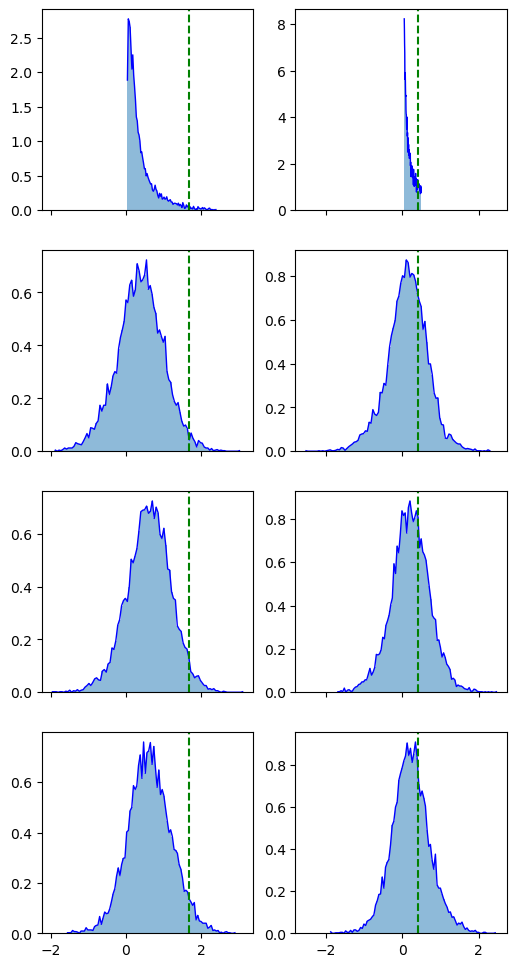

In [ ]:
from sfmpe.utils.plotting import dist_plot

sim_store = manager.store
posterior = manager.build_posterior()
dist_plot(sim_store.theta[0], 
                sim_store.theta[1],
                sim_store.theta[2],  
                posterior.sample((10000,)),
                # manager.clean_sample((1000, )),
                true_param=theta_0)

tensor([[1.6667, 0.4016]]) tensor([[0.6429, 0.2234]]) tensor([[0.5898, 0.5022]])


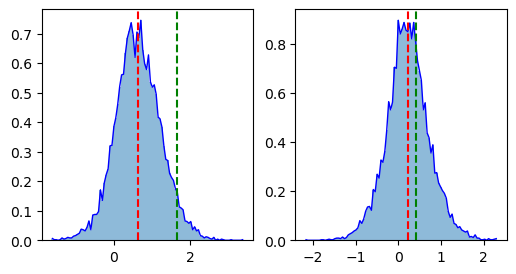

In [ ]:
pred = posterior.sample((10000,))
print(theta_0, pred.mean(dim=0), pred.std(dim=0))

def dist_plot2(*dists, true_param=None, pred_param=None):
        # assert len(dist1.shape) == len(dist2.shape) and dist1.shape[-1] == dist2.shape[-1]
        theta_dim = dists[0].shape[-1]
        num_bins  = [int(dists[i].shape[0] ** 0.5) for i in range(len(dists))]
        
        _, ax = plt.subplots(len(dists), theta_dim, sharex='col', figsize=(3*theta_dim, 3*len(dists)))
        if len(dists) == 1:
            ax = [ax]
        for j in range(theta_dim):
            for thetas, i in zip(dists, range(len(dists))):
                counts, bins, patches = ax[i][j].hist(thetas[:, :, j], bins=num_bins[i], alpha=0.5, density=True)

                bin_centers = (bins[:-1] + bins[1:]) / 2

                ax[i][j].plot(bin_centers, counts, 'b-', linewidth=1)

                if true_param is not None:
                    ax[i][j].axvline(x=true_param[:, j], linestyle='--', color='green')
                
                if pred_param is not None:
                    ax[i][j].axvline(x=pred_param[:, j], linestyle='--', color='red')

dist_plot2(pred, true_param=theta_0, pred_param=pred.mean(dim=0))

In [ ]:
flow_model.velocity_model.eval()
flow_model.velocity_model.to(x_0.device)

x_0 = params.x_0
x_0_expanded = x_0.unsqueeze(0).expand(1000, *x_0.shape)

theta_pred = flow_model.init_dist.sample((*x_0_expanded.shape[:-1],)).to(x_0_expanded.device)
t = torch.linspace(0, 1, steps=32 + 1).to(x_0_expanded.device)
        
with torch.no_grad():
    for i in range(32):
        theta_pred = flow_model.velocity_model.step(theta=theta_pred, x=x_0_expanded, t_start=t[i], t_end=t[i+1])
theta_pred = theta_pred.detach()

In [ ]:
# log_probs = posterior.log_prob(theta_pred)

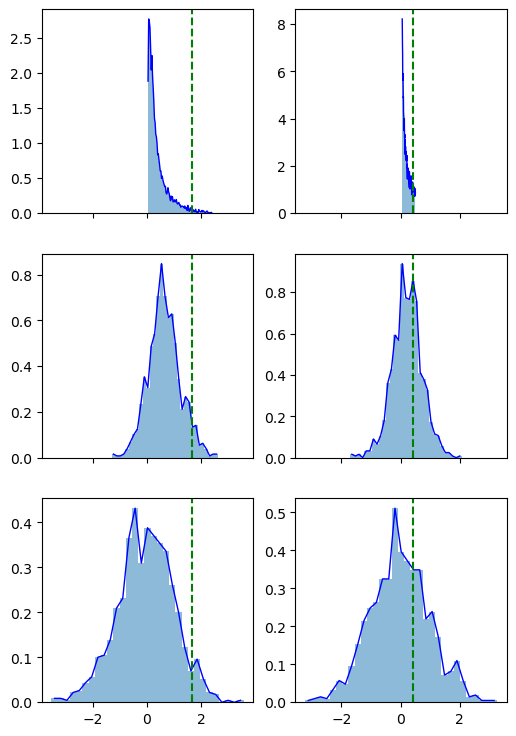

In [ ]:
dist_plot(sim_store.theta[0], 
                theta_pred, 
                flow_model.init_dist.sample((1000, 1, )).to(x_0_expanded.device),
                true_param=theta_0)

In [ ]:
# plt.scatter(theta_pred[..., 1], log_probs, c=log_probs)

In [ ]:
# exp = torch.exp(log_probs)
# plt.scatter(theta_pred[..., 1], exp, c=exp)
# plt.ylim(0, 10000)

In [ ]:
# samples = flow_model.init_dist.sample((10000,)) 
# logs = flow_model.init_dist.log_prob(samples)
# exp = torch.exp(logs)
# plt.scatter(samples[..., 0], exp, c=exp)

In [ ]:
# log_probs = posterior.log_prob(theta_pred)

# torch.quantile(log_probs, 0.15)
# baselogp, logp_corr = log_probs
# logp_pred = baselogp + logp_corr[-1]

In [ ]:
# mask = torch.where(log_probs <= torch.quantile(log_probs, 0.5))
# plt.scatter(theta_pred[mask][:, 0], theta_pred[mask][:, 1], s=1)
# plt.scatter(theta_0[:, 0], theta_0[:, 1], color="black", s=10)
# plt.xlim(0, 2.5)
# plt.ylim(0, 0.5)

In [ ]:
# from sfmpe.data.round_dataset import RoundDataset
# from sfmpe.data.simulation_store import SimulationStore


# init_dist = Uniform()
# v_model = SimpleVelocityField(task.theta_dim, task.data_dim, hidden_dim=64)
# path = AffinePath()
# flow = FlowModel(v_model, init_dist, path)

# optimizer = torch.optim.Adam(flow.parameters(), lr=1e-4)
# loss_fn = torch.nn.MSELoss()

# def preprocessor(theta, x, *args):
#     std_theta = torch.log(theta).std(dim=-1)
#     std_x     = x.std(dim=-1)
#     alpha_theta = 0.1
#     alpha_x     = 0.1
#     return torch.exp(torch.log(theta) + alpha_theta * std_theta * torch.randn_like(theta)), \
#                x + alpha_x * std_x * torch.randn_like(x)


# fm_estim = FlowMatchingEstimator(flow, optimizer, loss_fn, dataset_prepocessor=preprocessor)


# store = SimulationStore()
# theta, x = task.simulate_dataset((10000, ))
# store.add(theta, x, 0)
# dataset = RoundDataset(store, [0])

In [ ]:
# loss = fm_estim.train(dataset, epochs=2000, show_every=200)
# posterior = fm_estim.build_posterior()
# # plt.scatter(theta_0[:, 0], theta_0[:, 1], s=1)

In [ ]:
# theta, x = dataset.theta, dataset.x
# theta_1, x = preprocessor(theta, x)
# # theta_1 = torch.exp(torch.log(theta) + 0.1*torch.randn_like(theta))
# plt.scatter(torch.log(theta_1[:, 0]), torch.log(theta_1[:, 1]), s=1)

# theta.std(dim=0) * torch.randn_like(theta)

In [ ]:
# import corner

# for i in range(theta_pred.shape[1]):
#     samples = theta_pred[:, i, :].numpy()
#     fig = corner.corner(samples, bins=40, levels=[0.5], labels=['beta', 'gamma'],
#                         plot_datapoints=False, plot_contours=True, smooth=1)

In [ ]:
# def sbc(manager):
#     thetas_prior = manager.task.prior.sample((1000,))
#     num_samples = 1000
#     samples = manager.proposal.sample((num_samples, 1000,))
#     print(samples.shape, thetas_prior[:, None, None, :].shape)
#     ranks = (samples < thetas_prior[:, None, None, :]).sum(dim=-1)
#     print(ranks.shape)
#     return ranks


# ranks = sbc(manager)
# _, ax = plt.subplots(1, 2, figsize=(8, 2.5))
# ax[0].hist(ranks[:, 0].cpu(), bins=20, color="#8000ff")
# ax[1].hist(ranks[:, 1].cpu(), bins=20, color="orange")
